In [2]:
#Q1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv('/content/Airplane_Crashes_and_Fatalities_Since_1908.csv')
print("Dataset loaded successfully.")
display(df.head())

Dataset loaded successfully.


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [3]:
#Q2
rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.")



The dataset contains 5268 rows and 13 columns.


In [9]:
#Q3- Display the last 75 rows
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [17]:
#Q4- Treatment for missing data in each column (except the first)

"""
1. Time Column: Drop or impute with mode.
Dropping rows might lose valuable data on other fields.
Imputing with the most common time is a simple choice, but it can distort analysis.

2. Location Column: Fill with "Unknown" or Drop.
Missing values are very few.
Dropping these rows has a minimal impact on the dataset and ensures geographic analysis is accurate.
Alternatively, filling with "Unknown" preserves the row but limits its use in location-based tasks.

3. Operator:	Fill with "Unknown"
A missing operator doesn't invalidate the row's other information.
Filling with "Unknown" is appropriate as it preserves the record for analysis.

4. Flight #:	Drop Column
This column has a very high percentage of missing values.
It is unlikely to provide significant analytical value.

5. Route:	Fill with "Unknown"
Missing routes can be filled with "Unknown".
The route is descriptive and doesn't affect the calculation of other metrics.

6. Type: Fill with Mode
The aircraft type is important for analysis. The mode is a reasonable imputation if we assume that missing values are likely to be common aircraft types.
However, creating an "Unknown" category might be safer.

7. Registration	Drop Column
This unique identifier has very little analytical value for general trends and is often missing

8. cn/In:	Drop Column
This is another unique identifier. It has very little analytical value for general trends and is often missing.
Dropping it simplifies the dataset.

9. Aboard:	Impute with median
This is a numerical column. Imputing with the median is more robust to outliers than the mean.

10. Fatalities:	Impute with median
This is a numerical column. Imputing with the median is more robust to outliers than the mean.

11. Ground:	Fill with 0
The number of fatalities on the ground is often not applicable or recorded.
Filling missing values with 0 is logical, assuming that if a value is missing, it implies zero ground fatalities.

12. Summary:	Fill with "No summary available"
This is a text column. It cannot be easily imputed.
Filling with a placeholder string preserves the row while clearly indicating the gaps.
"""

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)*100).round(2)
})
missing_summary[missing_summary['Missing Values']>0]

,Missing Values,Percentage (%)
Time,2219,42.12
Location,20,0.38
Operator,18,0.34
Flight #,4199,79.71
Route,1707,32.40
Type,27,0.51
Registration,335,6.36
cn/In,1228,23.31
Aboard,22,0.42
Fatalities,12,0.23


In [20]:
#Q5
# dataframe with the specified columns
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()

# Display new dataframe
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [30]:
#Q6
#row with the maximum fatalities
max_fatality_idx = fatality_locations['Fatalities'].idxmax()


date_of_max_fatalities = fatality_locations.loc[max_fatality_idx, 'Date']

print(f"The date with the highest number of recorded fatalities is: {date_of_max_fatalities}")

The date with the highest number of recorded fatalities is: 03/27/1977


In [32]:
#Q7
# Compare the number of passengers aboard to the number of fatalities per crash.
print(fatality_locations[['Aboard', 'Fatalities']].describe())
# Are there any recorded crashes where there were no fatalities?
zero_fatalities_df = fatality_locations[fatality_locations['Fatalities'] == 0]
num_zero_fatalities = len(zero_fatalities_df)
# If so, how many?
print(f"\nNumber of recorded crashes with 0 fatalities: {num_zero_fatalities}")


            Aboard   Fatalities
count  5246.000000  5256.000000
mean     27.554518    20.068303
std      43.076711    33.199952
min       0.000000     0.000000
25%       5.000000     3.000000
50%      13.000000     9.000000
75%      30.000000    23.000000
max     644.000000   583.000000

Number of recorded crashes with 0 fatalities: 58


In [34]:
#Q8
# In the ‘fatality_locations’ dataframe, the location column has data items represented as ‘Region, U.S. State/Country’.
# Split this column to have two columns of regions and states/countries.
# Split from the right on the last comma to isolate the State/Country from the region/city
split_locations = fatality_locations['Location'].str.rsplit(',', n=1, expand=True)

fatality_locations['Region'] = split_locations[0].str.strip()
fatality_locations['Country_State'] = split_locations[1].str.strip()

fatality_locations[['Location', 'Region', 'Country_State']].head()


,Location,Region,Country_State
0,"Fort Myer, Virginia",Fort Myer,Virginia
1,"AtlantiCity, New Jersey",AtlantiCity,New Jersey
2,"Victoria, British Columbia, Canada","Victoria, British Columbia",Canada
3,Over the North Sea,Over the North Sea,None
4,"Near Johannisthal, Germany",Near Johannisthal,Germany


In [35]:
#Q9
# Order the dataframe by the number of fatalities from highest to lowest and select the first 100.
top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)
top_100_fatalities

,Date,Location,Aboard,Fatalities,Region,Country_State
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


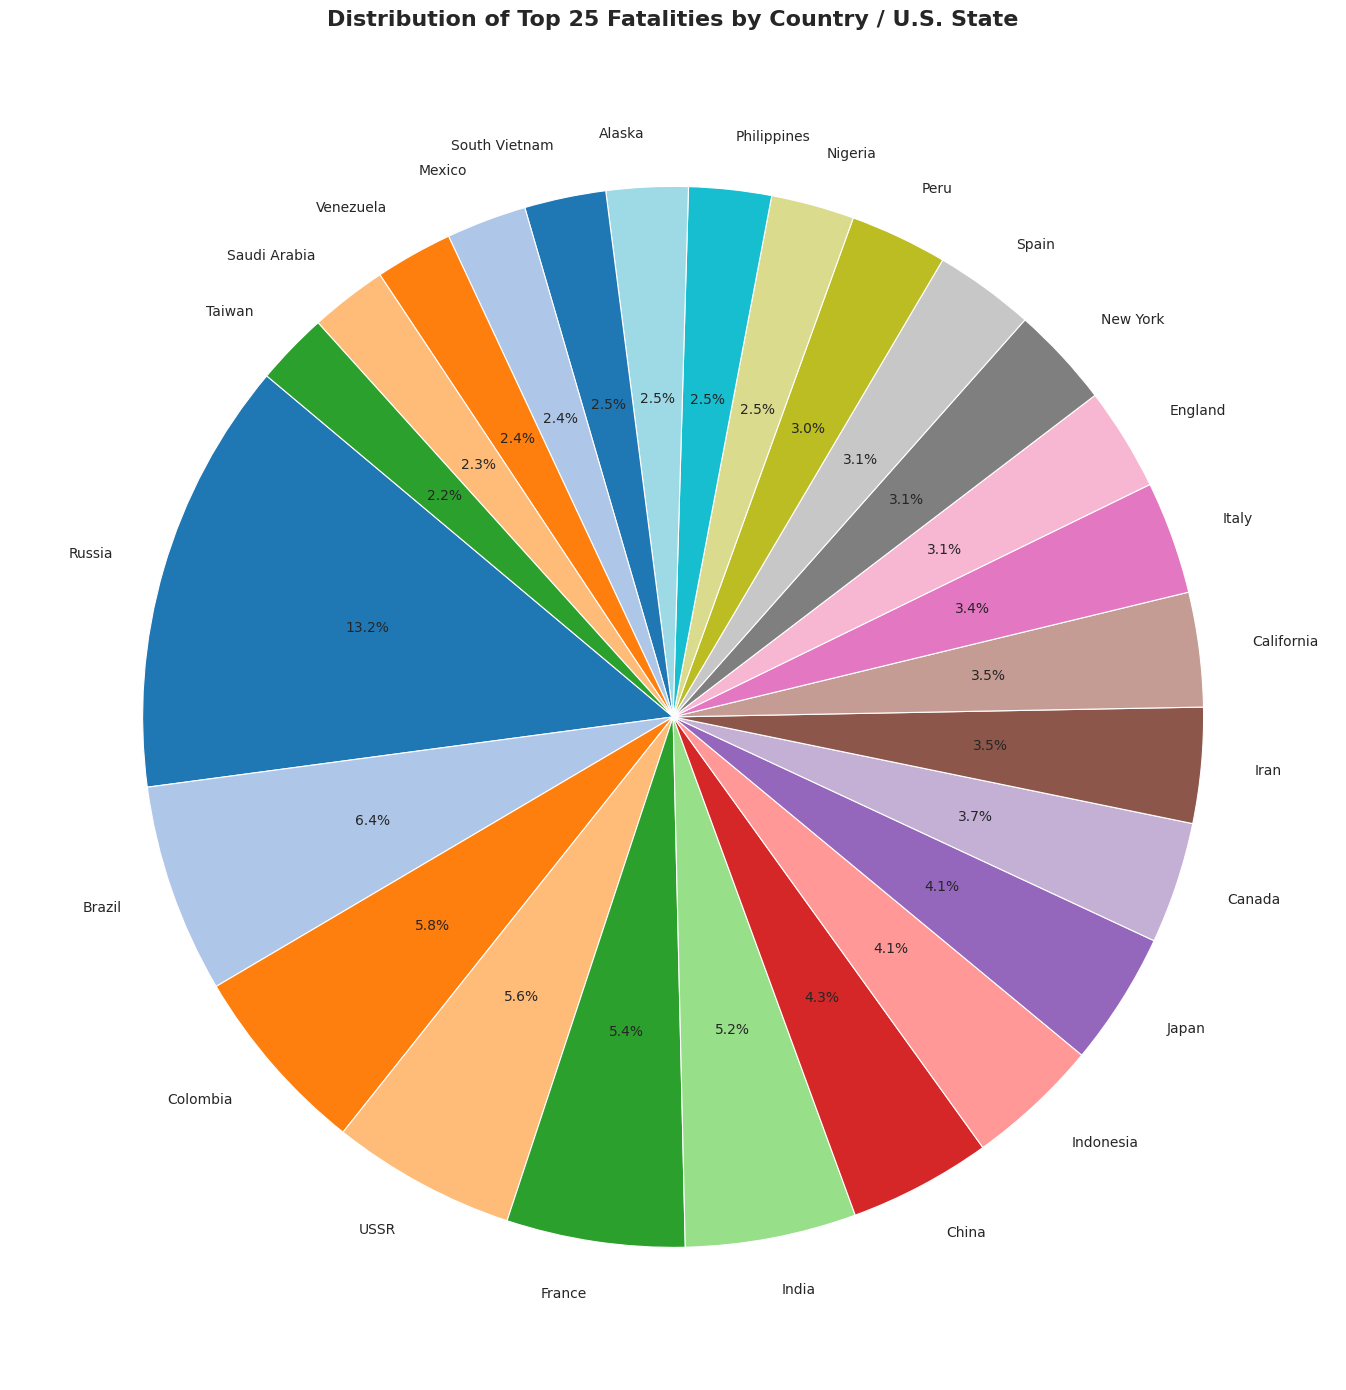

In [42]:
# Q10
#  Generate a pie chart that shows the distribution of the top 25 number of fatalities per country/U.S. State.
top_25_fatalities = (
    fatality_locations.groupby('Country_State')['Fatalities']
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

# pie chart
plt.figure(figsize=(14, 14))
colors = sns.color_palette('tab20', n_colors=len(top_25_fatalities))

plt.pie(
    top_25_fatalities.values,
    labels=top_25_fatalities.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.8}
)

plt.title('Distribution of Top 25 Fatalities by Country / U.S. State', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

In [43]:
!git status

fatal: not a git repository (or any of the parent directories): .git
